In [ ]:
import nltk

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('./results', exist_ok=True)

with open('./brown_100.txt', 'r') as file_:
    corpus = file_.read()

def write_freqs(list_: list, filename: str) -> None:
    with open(f'./results/{filename}.txt', 'w') as file_:
        file_.write('\n'.join([' '.join(x[0]) + ' | ' + str(x[1]) for x in list_]))

## N-Gram Language Modeling
In the second assignment, you will implement an **n-gram language model** that processes input text to generate, analyze, and calculate the probabilities of sequences of `n` words (n-grams). This model will tokenize text, create n-grams, and compute their frequencies and probabilities, returning the most frequent n-grams in the text.

1. **Tokenization**: Convert the input text into a list of words (tokens).
2. **N-gram Generation**: Create sequences of `n` tokens from the text, treating each sentence independently with the inclusion of start (`<s>`) and end (`</s>`) markers.
3. **Frequency Counting**: Count how many times each n-gram appears in the text.
4. **Probability Calculation**: Compute the probabilities of each n-gram based on its frequency and add alpha smoothing to improve generalization of items.
5. **Most Frequent N-grams**: Return the most frequent n-grams along with their probabilities, helping to identify common patterns in the text.

In [2]:
from collections import Counter, defaultdict # You may import more from collections if needed

class NGramModel:
    def __init__(self, text, n, alpha=0.0):
        """
        Initialize the NGramModel with text and the value of n.
        """
        self.text = text
        self.n = n
        self.alpha = alpha  # Alpha value for additive smoothing
        # Added self.list_ngrams variable to store the ngrams as a list
        self.list_ngrams = []
        self.ngrams = {}
        self.probabilities = {}
        self.vocab = set()

    def tokenize(self) -> list:
        """
        Tokenize the text into words. 
        Fill in the code to split the text into a list of words.
        """
        # Split by whitespace
        tokens = self.text.split()

        return tokens

    def generate_ngrams(self, tokens: list) -> list:
        """
        Generate n-grams from the list of tokens.
        Fill in the code to create n-grams.
        Make sure to treat each sentence independently, include the <s> and </s> tokens.
        """
        # Reset the ngrams list
        self.list_ngrams = []

        # Treat each sentence independently
        sentence = []

        for token in tokens:
            # Start sentence when start of sentence token is encountered
            if token == "<s>":
                sentence = ["<s>"]
                continue
            sentence.append(token)

            if token == "</s>":
                sentence = []
                continue

            if len(sentence) >= self.n:
                # Create the n grams as tuples and add the ngram to the list of ngrams
                self.list_ngrams.append(tuple(sentence[-self.n:]))

        # The template provided for this assignment indicated that this function is meant to return 
        # a list, while self.ngrams is defined as a dictionary. Thus we changed the type hint to dict.
        return self.list_ngrams

    def count_frequencies(self) -> None:
        """
        Count the frequencies of each n-gram.
        Fill in the code to count n-gram occurrences.
        """
        # Use the list of ngrams to populate the dictionary
        for i in self.list_ngrams:
            if i in self.ngrams:
                self.ngrams[i] += 1
            else:
                self.ngrams[i] = 1

    def calculate_probabilities(self) -> None:
        """
        Calculate probabilities of each n-gram based on its frequency. Add alpha smoothing separately.
        """
        # Total number of ngrams in the dataset
        total_ngrams = sum(self.ngrams.values())
        # For smoothing, unique number of n grams
        V = len(self.ngrams)
        for ngram, count in self.ngrams.items():
            self.probabilities[ngram] = (count + self.alpha) / (total_ngrams + (self.alpha * V))

    def most_frequent_ngrams(self, top_n: int = 10) -> list:
        """
        Return the most frequent n-grams and their probabilities.
        """
        # Sort the frequency first
        sorted_ngrams = sorted(self.ngrams.items(), key=lambda x: x[1], reverse=True)[:top_n]
        # Sort the probabilities based on the frequency
        sorted_grams = [(ngram, self.probabilities.get(ngram, 0)) for ngram,_ in sorted_ngrams]
    
        return sorted_grams

# Testing the model with an example
text = "This is a simple example to demonstrate how n-grams work in this assignment." #Faster than running the full corpus
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(text, n)

tokens = model.tokenize()

model.generate_ngrams(tokens)
model.count_frequencies()

model.calculate_probabilities()

# Print the most frequent n-grams
print(model.most_frequent_ngrams(10))

[(('This', 'is'), 0.08333333333333333), (('is', 'a'), 0.08333333333333333), (('a', 'simple'), 0.08333333333333333), (('simple', 'example'), 0.08333333333333333), (('example', 'to'), 0.08333333333333333), (('to', 'demonstrate'), 0.08333333333333333), (('demonstrate', 'how'), 0.08333333333333333), (('how', 'n-grams'), 0.08333333333333333), (('n-grams', 'work'), 0.08333333333333333), (('work', 'in'), 0.08333333333333333)]


### Unigrams

In this section, we apply the `NGramModel` to our corpus. The model can be configured to generate unigrams, bigrams, or trigrams by adjusting the value of `n`. After tokenizing the text and generating the n-grams, the model counts the occurrences of each n-gram and calculates their probabilities. The most frequent n-grams are then written to an output file.

By adjusting the n-gram size, we can analyze different levels of word dependencies in the text, providing insights into common word sequences and patterns.  

The code below will generate unigrams when the NGramModel is implemented correctly

In [3]:
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'unigrams')

### Bigrams
Bigrams allow us to explore word pairs and their relationships, providing insight into common word combinations and phrase structures within the corpus.  
The code below will generate bigrams when the NGramModel is implemented correctly.

In [4]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams')

### Trigrams
Trigrams capture three-word sequences, providing a deeper understanding of longer word dependencies and commonly occurring phrases within the text.  
The code below will generate trigrams when the NGramModel is implemented correctly

In [5]:
n = 3  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'trigrams')

### Smoothing
Below, we generate **bigrams** with **smoothing** applied by setting `n = 2` and including a smoothing parameter `alpha = 1.0`. Smoothing is useful in language models to handle unseen n-grams by assigning a small probability to them. The model tokenizes the text, generates bigrams, counts their frequencies, and calculates smoothed probabilities. The most frequent bigrams are then written to an output file.





In [6]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n, alpha=1.0)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams_smoothed')

### Generating Text
In this example, we generate text using the **bigrams** model by providing a starting **prompt** (e.g., "the jury"). The `generate_text` function creates a sequence of words based on the trained bigram model, starting from the provided prompt and continuing based on the probabilities of the next words.

After tokenizing the corpus, generating bigrams, and calculating their frequencies and probabilities, the model uses these learned probabilities to generate text. The generated output is then written to a file.

Text generation with n-grams helps illustrate how language models can predict word sequences, allowing us to create new sentences that follow similar patterns found in the original text.

In [7]:
import random
def generate_text(model: NGramModel, n: int, prompt: str) -> str:
    # Split into initial tokens
    generated_tokens = prompt.split()

    while True:
        context_window = n - 1
        # Get the contect from the generated tokens
        context = tuple(generated_tokens[-(context_window):]) if n > 1 else tuple()

        # Candidates for the next word according to the context
        candidates = []
        for ngram, probability in model.probabilities.items():
            ngram_context = ngram[:-1]
            next_word = ngram[-1]
            if ngram_context == context:
                candidates.append((ngram[-1], probability)) 
        # Stop the generated text if there are no valid next words
        if not candidates:
            break

        # Get the words and their probabilities
        words = []
        probs = []

        for word, prob in candidates:
            words.append(word)
            probs.append(prob)
        # Choose the next word based on the probabilities
        next_word = random.choices(words, weights=probs, k=1)[0]
        generated_tokens.append(next_word)

        # Stop if the end of sentence token is generated
        if next_word == "</s>":
            break

    return ' '.join(generated_tokens)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()
generated_text = generate_text(model, 2, 'the jury')
with open(f'./results/generated_bigrams.txt', 'w') as file_:
    file_.write(generated_text)

## Word Vectors
Note: This part of the notebook was originally written for a corpus based on movie reviews from IMDb, based on a Stanford course (https://web.stanford.edu/class/cs224n/). Part of your task is to adapt this portion of the notebook to the corpora used in the previous parts of the assignment: namely, the Brown Corpus and the Indian Language Corpus. You will need to access these corpora from NLTK and perform all functions for both corpora. Note down any updates in the code in your comments.

### Count based W2V
In this section, we use the previously trained **n-gram model** to calculate a **co-occurrence matrix**. A co-occurrence matrix shows how often words appear together within a specific context (in this case, bigrams), providing insights into word relationships in the corpus.

Steps:
1. **Tokenization and N-gram Generation**: We first tokenize the text and generate bigrams using the `NGramModel`.
2. **Vocabulary and Indexing**: The vocabulary is created from the unique tokens, and a word-to-index mapping is established.
3. **Co-occurrence Matrix**: Using the generated n-grams, we compute the co-occurrence matrix, where each entry represents how often two words occur together within the bigrams.

The co-occurrence matrix provides a numerical representation of word relationships, which is useful for tasks like word embeddings, semantic analysis, and understanding word associations.

In [9]:
# Since we already have a working ngram model, for the next part we can use the ngrams to calculate the co-occurences.
model = NGramModel(corpus, 2)
tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
print(ngrams)

def create_co_matrix(ngrams: list, vocab_size: int, word_to_index: dict) -> np.ndarray:
    # V = size of vocabulary; N = number of documents -> number of words
    V = vocab_size

    # create a word x word matrix
    co_matrix = np.zeros(shape=(V, V), dtype = np.int8)

    for bigram in ngrams:
        w1 = bigram[0]
        w2 = bigram[1]

        i = word_to_index[w1]
        j = word_to_index[w2]

        co_matrix[i, j] += 1

    return co_matrix

# creates a list of all unique tokens
vocab = list(set(tokens))
# len of vocab list
vocab_size = len(vocab)

# Create a word-to-index mapping
word_to_index = {word: idx for idx, word in enumerate(vocab)}

# Generate the co-occurrence matrix
co_matrix = create_co_matrix(ngrams, vocab_size, word_to_index)

# Optionally, print the matrix or parts of it
print(co_matrix)

[('<s>', 'The'), ('The', 'Fulton'), ('Fulton', 'County'), ('County', 'Grand'), ('Grand', 'Jury'), ('Jury', 'said'), ('said', 'Friday'), ('Friday', 'an'), ('an', 'investigation'), ('investigation', 'of'), ('of', "Atlanta's"), ("Atlanta's", 'recent'), ('recent', 'primary'), ('primary', 'election'), ('election', 'produced'), ('produced', '``'), ('``', 'no'), ('no', 'evidence'), ('evidence', "''"), ("''", 'that'), ('that', 'any'), ('any', 'irregularities'), ('irregularities', 'took'), ('took', 'place'), ('place', '.'), ('<s>', 'The'), ('The', 'jury'), ('jury', 'further'), ('further', 'said'), ('said', 'in'), ('in', 'term-end'), ('term-end', 'presentments'), ('presentments', 'that'), ('that', 'the'), ('the', 'City'), ('City', 'Executive'), ('Executive', 'Committee'), ('Committee', ','), (',', 'which'), ('which', 'had'), ('had', 'over-all'), ('over-all', 'charge'), ('charge', 'of'), ('of', 'the'), ('the', 'election'), ('election', ','), (',', '``'), ('``', 'deserves'), ('deserves', 'the'), (

With the code below you can verify if the co-occurence works

In [10]:
def check_co_occurrence(word1, word2, co_matrix, word_to_index):
    """
    Print the co-occurrence count for a specific word pair.
    """
    if word1 not in word_to_index or word2 not in word_to_index:
        print(f"One or both words '{word1}' and '{word2}' are not in the vocabulary.")
        return

    index1 = word_to_index[word1]
    index2 = word_to_index[word2]

    co_count = co_matrix[index1][index2]
    print(f"Co-occurrence count for '{word1}' and '{word2}': {co_count}")

check_co_occurrence('the', 'jury', co_matrix, word_to_index)
check_co_occurrence('the', 'cat', co_matrix, word_to_index)

#note: check co-occurrences of word pairs relevant to your corpora, commenting why these pairs are interesting

Co-occurrence count for 'the' and 'jury': 7
One or both words 'the' and 'cat' are not in the vocabulary.


In this part, we reduce the dimensionality of the **co-occurrence matrix** using **Singular Value Decomposition (SVD)**. This technique helps in extracting the most important features from the matrix, making it easier to visualize and interpret the relationships between words.

Steps:
1. **Singular Value Decomposition (SVD)**: The co-occurrence matrix is decomposed into three matrices: \( M = U \cdot \Sigma \cdot V^T \).
2. **Dimensionality Reduction**: We retain only the top `k` components (default is 2) from the SVD, effectively reducing the dimensionality of the matrix.
3. **Reduced Matrix**: The reduced matrix retains the most important semantic information and can be used for tasks such as **word embedding visualization** or **semantic similarity analysis**.

Dimensionality reduction allows us to capture the essence of word relationships in fewer dimensions, making it more efficient to process and visualize the data.

In [15]:
def reduce_to_k_dim(M, k=2):
    
    # compress the matrix while keeping important patterns 
    # ( M = U \cdot \Sigma \cdot V^T \).
    U, S, Vh = np.linalg.svd(M, full_matrices=False)

    # U is a matrix, rows = words and columns = features
    # we keep all rows, and keep only the first 2 columns
    U_vector = U[:,:k]
    # keep only 2 important features - 2 columns - scale
    S_vector = S[:k]
    Vh_vector = Vh[:k]

    # Scaling the patterns by their importance
    M_reduced = U_vector @ np.diag(S_vector)

    return M_reduced

In this final part, we visualize the reduced word embeddings in **2D space**. After reducing the dimensionality of the co-occurrence matrix using SVD, we plot the embeddings for each word to observe their relationships in a low-dimensional space.

Steps:
1. **Plotting the Embeddings**: Each word from the vocabulary is plotted based on its 2D coordinates from the reduced matrix.
2. **Visualization**: The scatter plot allows us to see how words cluster together or relate to each other based on co-occurrences in the text. Words with similar contexts should appear closer to each other in the plot.
3. **Interpretation**: By looking at the 2D plot, we can analyze word similarities, relationships, and clusters formed by words that often occur together.

This visualization is a useful tool for understanding the structure of word embeddings and the relationships between words in the corpus.

In [25]:
print(vocab)

['very', 'rural', 'praise', 'outmoded', 'employes', 'remedy', 'offices', 'resigned', 'him', 'too', 'unmeritorious', 'interim', 'specifically', 'opposes', 'effect', 'consistently', 'consulted', 'got', 'enthusiasm', 'something', 'coolest', 'act', 'Mayor-nominate', 'Implementation', 'elaborate', 'son', 'years', 'Police', 'trouble', 'His', 'goes', 'earlier', 'When', 'divorce', 'former', 'end', 'distribution', 'legislator', 'veiled', 'W.', 'produced', 'serve', 'taken', 'Washington', 'They', 'considering', 'violence', 'take', 'populous', "Department's", 'weekend', 'the', 'airport', 'welfare', 'services', 'state', 'Ala.', 'so', 'implementation', 'back', 'committee', 'starts', 'Jan.', 'dispute', 'fire', 'policeman', 'distribute', 'Court', 'members', 'On', 'Pye', 'steps', 'fees', 'Sunday', 'improving', '13th', 'platform', 'will', 'petitions', '87-31', 'ever', 'his', 'unanimous', 'three', '$30', 'protected', 'takes', 'Tax', 'feared', 'Henry', 'had', 'size', 'major', 'after', 'let', 'investigatio

In [39]:
nltk.download("stopwords")
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soori\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\soori\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
stop_words = stopwords.words('english')
tagged_vocab = nltk.pos_tag(vocab)
punctuation = punctuation = {'<s>', '</s>', '``', "''", '--', '.', ',', ':', ';', '(', ')'}

extra_remove = {
    'something', 'none', 'bit', 'time', 'day', 'days', 'year', 'years','end', 'top', 'work', 'fact', 
    'result', 'issue', 'issues', 'word', 'place', 'ones', 'number', 'side', 'part', 'member', 'members', 
    'take', 'let', 'ask', 'give', 'seek', 'enter', 'fit', 'insure','determine', 'realize', 'continue',
    'mention', 'making', "body's", "wife's", "governor's", "mayor's", "weekend", "$30", "$100",
      "cent", 'afternoon'
    }

clean_words = []

for item in tagged_vocab:
    word = item[0]
    tag = item[1]

    if word.lower() not in stop_words and word not in punctuation and word.lower() not in extra_remove:
        if tag == "NN" or tag == "NNS":
            clean_words.append(word)

print(clean_words)
print(len(clean_words))


['praise', 'remedy', 'offices', 'effect', 'elaborate', 'son', 'trouble', 'divorce', 'distribution', 'legislator', 'violence', 'airport', 'welfare', 'services', 'state', 'implementation', 'committee', 'dispute', 'fire', 'steps', 'fees', 'platform', 'size', 'investigation', 'increase', 'occupation', 'manner', 'privilege', 'portion', 'speaker', 'departments', 'areas', 'term', 'thanks', 'jail', 'school', 'county', 'night', 'crowd', 'validity', 'assistance', 'director', 'source', 'church', 'road', 'highway', 'unit', 'promise', 'brief', 'cost', 'policies', 'battle', 'session', 'chairman', 'names', 'sales', 'reconsideration', 'education', 'controversy', 'pass', 'authorities', 'encouragement', 'liquor', 'protests', 'actions', 'outgoing', 'petition', 'problem', 'courts', 'reconstruction', 'expense', 'jurors', 'board', 'primary', 'warning', 'charge', 'plan', 'handful', 'visit', 'quickie', 'court', 'administrators', 'gubernatorial', 'registration', 'date', 'amendment', 'homes', 'personnel', 'suit

In [56]:
['praise', 'remedy', 'offices', 'effect', 'elaborate', 'son', 'trouble', 'divorce', 'distribution', 'legislator', 'violence', 'airport', 'welfare', 'services', 'state', 'implementation', 'committee', 'dispute', 'fire', 'steps', 'fees', 'platform', 'size', 'investigation', 'increase', 'occupation', 'manner', 'privilege', 'portion', 'speaker', 'departments', 'areas', 'term', 'thanks', 'jail', 'school', 'county', 'night', 'crowd', 'validity', 'assistance', 'director', 'source', 'church', 'road', 'highway', 'unit', 'promise', 'brief', 'cost', 'policies', 'battle', 'session', 'chairman', 'names', 'sales', 'reconsideration', 'education', 'controversy', 'pass', 'authorities', 'encouragement', 'liquor', 'protests', 'actions', 'outgoing', 'petition', 'problem', 'courts', 'reconstruction', 'expense', 'jurors', 'board', 'primary', 'warning', 'charge', 'plan', 'handful', 'visit', 'quickie', 'court', 'administrators', 'gubernatorial', 'registration', 'date', 'amendment', 'homes', 'personnel', 'suit', 'chambers', 'office', 'automobile', 'audience', 'calls', 'future', 'teacher', 'wind', 'laws', 'event', 'approval', 'priority', 'awarding', 'modernizing', 'program', 'deputies', 'management', 'swipe', 'presentments', 'juries', 'daughter', 'costs', 'system', 'delegation', 'party', 'achieve', 'revolving', 'voters', 'topics', 'research', 'permit', 'repair', 'resolution', 'money', 'matters', 'age', 'duty', 'farms', 'interest', 'mayor', 'jury', 'support', 'construction', 'department', 'attorney', 'law', 'highways', 'home', 'face', 'phone', 'tax', 'sessions', 'proportionate', 'requesting', 'pension', 'Failure', 'bankers', 'legislation', 'telephone', 'ballot', 'servants', 'exception', 'evidence', 'race', 'legislators', 'practices', 'drop', 'man', 'offer', 'surveillance', 'post', 'officials', 'influences', 'prices', 'allowances', 'disproportionate', 'threats', 'efficiency', 'election', 'property', 'appointment', 'bond', 'death', 'action', 'council', 'agriculture', 'items', 'administration', 'hold', 'handling', 'reelection', 'investigate', 'contracts', 'issuance', 'official', 'meeting', 'plans', 'adjournment', 'campaign', 'study', 'pistol', 'child', 'governments', 'candidates', 'bonds', 'guardians', 'polls', 'coordinator', 'hopper', 'taxpayers', 'order', 'foster', 'reports', 'raises', 'prison', 'fund', 'compensation', 'appraisers', 'force', 'dissents', 'city', 'relations', 'recommendations', 'emphasizing', 'voting', 'congressmen', 'votes', 'roads', 'couple', 'vote', 'sign', 'resignation', 'details', 'operation', 'signatures', 'wife', 'superintendent', 'inure', 'head', 'settlement', 'career', 'feel', 'adjustments', 'funds', 'test']


['praise',
 'remedy',
 'offices',
 'effect',
 'elaborate',
 'son',
 'trouble',
 'divorce',
 'distribution',
 'legislator',
 'violence',
 'airport',
 'welfare',
 'services',
 'state',
 'implementation',
 'committee',
 'dispute',
 'fire',
 'steps',
 'fees',
 'platform',
 'size',
 'investigation',
 'increase',
 'occupation',
 'manner',
 'privilege',
 'portion',
 'speaker',
 'departments',
 'areas',
 'term',
 'thanks',
 'jail',
 'school',
 'county',
 'night',
 'crowd',
 'validity',
 'assistance',
 'director',
 'source',
 'church',
 'road',
 'highway',
 'unit',
 'promise',
 'brief',
 'cost',
 'policies',
 'battle',
 'session',
 'chairman',
 'names',
 'sales',
 'reconsideration',
 'education',
 'controversy',
 'pass',
 'authorities',
 'encouragement',
 'liquor',
 'protests',
 'actions',
 'outgoing',
 'petition',
 'problem',
 'courts',
 'reconstruction',
 'expense',
 'jurors',
 'board',
 'primary',
 'warning',
 'charge',
 'plan',
 'handful',
 'visit',
 'quickie',
 'court',
 'administrators',


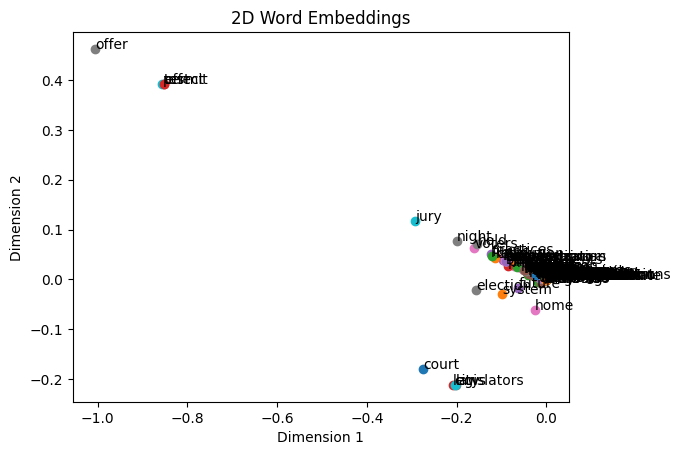

In [85]:
def plot_embeddings(M_reduced, words, word_to_index):
    plt.figure()

    for word in words:
        if word in word_to_index:
            idx = word_to_index[word]
            x = M_reduced[idx, 0]
            y = M_reduced[idx, 1]

            plt.scatter(x, y)
            plt.text(x, y, word)

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title("2D Word Embeddings")
    plt.show()

# words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

words = clean_words
#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do
M = co_matrix
M_reduced = reduce_to_k_dim(M, k=2)
plot_embeddings(M_reduced, words, word_to_index)

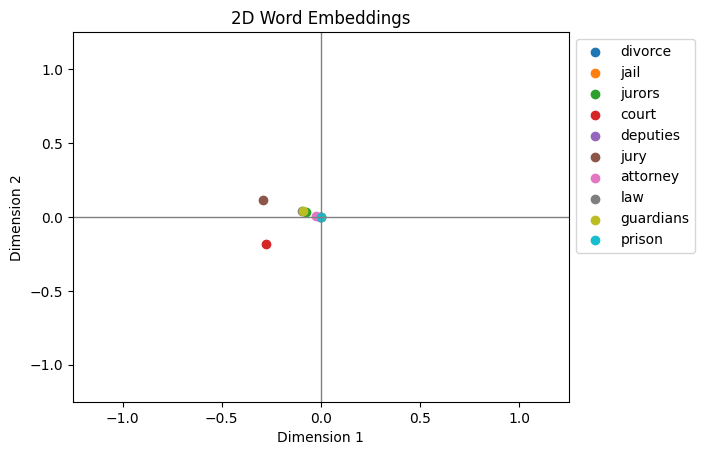

In [118]:
def plot_embeddings(M_reduced, words, word_to_index):
    plt.figure()

    for word in words:
        if word in word_to_index:
            idx = word_to_index[word]
            x = M_reduced[idx, 0]
            y = M_reduced[idx, 1]

            plt.scatter(x, y, label = word)


    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title("2D Word Embeddings")
    plt.xlim(-1.25, 1.25)
    plt.ylim(-1.25, 1.25)
    plt.axhline(0, color='gray', linewidth=1)  
    plt.axvline(0, color='gray', linewidth=1)  
    plt.legend(bbox_to_anchor = (1, 1) ,loc= 'upper left')
    plt.show()


#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do
words = [
 'divorce',
 'jail',
 'jurors',
 'court',
 'deputies',
 'jury',
 'attorney',
 'law',
 'guardians',
 'prison',]

M = co_matrix
M_reduced = reduce_to_k_dim(M, k=2)
plot_embeddings(M_reduced, words, word_to_index)

We first cleaned vocabulary by removing stop words, punctuation, non non informative tokens. Then, we restricted the vocabulary to Nouns, as they might be semenatically more informative for anayzing relationships between words. By doing that, we reduced the word count from 13657 to 300 words. However, some less relevant items such as numerival values '$30' and common words 'wife', 'son' remained. This further reduced to 235 words. Visualizing all remaining words resulted in a cluttered and difficult-to-interpret plot. Therefore, we strated to group words based on themes like election, court, crime... in order to collect a subset of semantically related words. This targeted selection reduced visual clutter and allows for clearer observation of semantic relationships between words that occur in similar contexts.

In the 2D plot, several legal terms appear relatively close to one another, suggesting that they occur in similar contexts within the corpus. For example, words such as attorney, divorce, jail, deputies, and prison form a small cluster, indicating that they are often used in related legal or judicial situations. Similarly, words like law, guardians, and jurors also appear close together, reflecting shared contextual usage.

Interestingly, some words do not cluster as expected. For instance, jury and court are positioned relatively far apart, despite their strong conceptual relationship. This may be due to differences in how these terms are used in the corpus (e.g., appearing in different contexts or sentence structures).

Another notable observation is that divorce appears close to prison, which may seem unintuitive. This likely reflects limitations of the model and the data embeddings depend on local context.

Overall, while the visualization captures some meaningful semantic relationships. The reduction to two dimensions leads to information loss, and therefore not all relationships are perfectly represented in the plot.

## Prediction-Based Word Vectors
In this section, we load pre-trained word vectors using the **GloVe** embeddings from the [Stanford NLP paper on GloVe](https://nlp.stanford.edu/pubs/glove.pdf). The pre-trained embeddings provide rich semantic information about words based on large text corpora, allowing us to represent words as vectors that capture their meaning and relationships.

Steps:
1. **Load GloVe Word Vectors**: We use the GloVe embeddings from the `glove-wiki-gigaword-200` model, which has 200-dimensional vectors for each word.
2. **Vocabulary Matching**: We map the words from our corpus to the GloVe vocabulary and extract the corresponding vectors.
3. **Dimensionality Reduction**: After obtaining the word vectors, we reduce the dimensionality to visualize the embeddings in 2D space, allowing us to explore word relationships visually.

This is an excellent opportunity to explore how pre-trained embeddings like GloVe can be used to improve downstream NLP tasks by providing richer word representations.

In [106]:
# Do not edit
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

wv_words = list(wv_from_bin.index_to_key)
unique_tokens = set(tokens)
word2ind = {}
M = []
idx = 0
print('rendering M based on wv')
for w in wv_words:
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass

print('rendering M based on unique_tokens')
for w in unique_tokens:
    if w in wv_words:
        continue
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass
M = np.stack(M)
M_reduced = reduce_to_k_dim(M, k=2)

M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]

[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000
rendering M based on wv
rendering M based on unique_tokens


### Compare plots
What stands out when comparing the two different ways of embedding using the given words?

(Use this to help answer the question in your assignment document).

In order to better compare the two visualization, we fixed the axis limits to the range [-1.25, 1.25] in order to archieve a more meaningful comparision. 

While a main cluster is still visible, several words are positioned further away from it, such as guardians and attorney, indicating clearer separation between certain semantic concepts.

Additionally, some relationships differ between the two plots. In the count-based embedding, jury and court were positioned relatively far apart, whereas in the GloVe embedding they appear closer together.


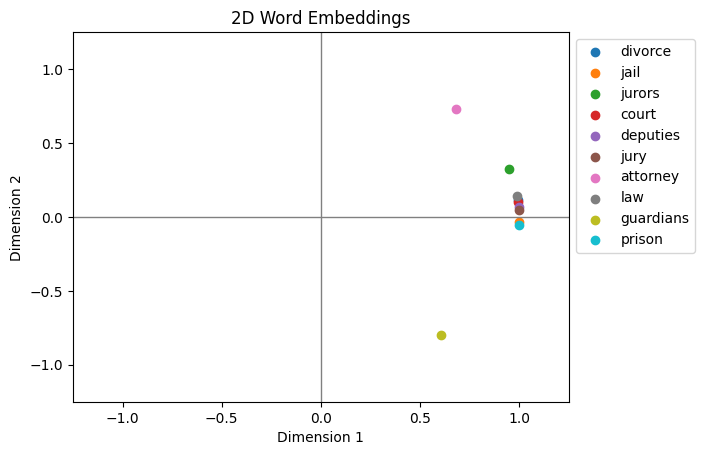

In [119]:
plot_embeddings(M_reduced_normalized, words, word2ind)

### Words with multiple meanings
Polysemes and homonyms are words that have more than one meaning (see [this wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms). Your task is to find a word with at least two different meanings such that the top-10 most similar words (according to cosine similarity) contain related words from both meanings.

For example:
- "leaves" has both the "go_away" and "a_structure_of_a_plant" meanings in the top 10.
- "scoop" has both "handed_waffle_cone" and "lowdown" meanings in the top 10.

You will probably need to try several polysemous or homonymic words before you find one.

Once you discover a word that fits this criterion, state the word and explain the multiple meanings that occur in the top 10. Reflect on why many of the polysemous or homonymic words you tried didn’t work (i.e., why the top-10 most similar words only contain one of the word's meanings).

**Note**: Use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary based on their cosine similarity to the given word. For further assistance, you can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [ ]:
words = ['advice', 'buy', 'cell', 'council', 'desert', 'i', 'hi', 'plane', 'sea', 'bank', 'bow', 'current', 'date', 'fair', 'firm', 'lie', 'match', 'nail', 'park', 'ring', 'rock', 'spring', 'tender', 'can', 'cool', 'light', 'order', 'page', 'space', 'train', 'type', 'wave', 'watch', 'right', 'left', 'close', 'letter', 'season', 'tie', 'capital', 'sign', 'drop', 'capture', 'address', 'fall']

for word in words:
    print(word, wv_from_bin.most_similar(word, topn=10))

advice [('ask', 0.6118823289871216), ('advise', 0.5998780131340027), ('asking', 0.5990046858787537), ('suggestions', 0.5906529426574707), ('guidance', 0.5886049866676331), ('advised', 0.5772797465324402), ('answer', 0.5684024095535278), ('answers', 0.5585401058197021), ('opinions', 0.5564491748809814), ('providing', 0.5516985654830933)]
buy [('sell', 0.8963040113449097), ('purchase', 0.8143855333328247), ('buying', 0.756690263748169), ('bought', 0.7454342842102051), ('sale', 0.701101541519165), ('acquire', 0.7006138563156128), ('sold', 0.6804332137107849), ('buys', 0.6612627506256104), ('selling', 0.6528139114379883), ('sells', 0.6517484784126282)]
cell [('cells', 0.8123843669891357), ('cellular', 0.6800376176834106), ('phones', 0.6146423816680908), ('phone', 0.5800527334213257), ('embryonic', 0.5504643321037292), ('stem', 0.5373920798301697), ('tissue', 0.5371425151824951), ('membrane', 0.5362494587898254), ('brain', 0.526643693447113), ('mobile', 0.518550455570221)]
council [('commis

We tested several homonymous and polysemous words using wv_from_bin.most_similar(word). For the word 'ring', we obtained the following words: [('rings', 0.8160920143127441), ('diamond', 0.49073681235313416), ('five-membered', 0.4714858829975128), ('outer', 0.46931296586990356), ('triangle', 0.4620662033557892), ('smuggling', 0.4527536630630493), ('connected', 0.4509718418121338), ('trafficking', 0.4382753074169159), ('endomorphism', 0.4380123019218445), ('belt', 0.4353186786174774)].

In the top-10 most similar words, we observe multiple meanings of ring. Words such as diamond and rings correspond to the jewellery sense, while triangle, five-membered, and endomorphism reflect the geometric or mathematical sense. Additionally, smuggling and trafficking relate to the criminal-group sense. This demonstrates that the embedding captures multiple meanings of the word. 

It took many attempts because many words did not show multiple meanings. It might be due to the fact that the words are captured in word embedding, word without its context is less accurate than when it appears within n-grams or surrounding context. As a result, the representation might be influenced by the most frequent meaning in the training set. Therefore, the top-10 most similar words tend to reflect only one sense, even when the word is polysemous.

### Synonyms
When considering **Cosine Similarity**, it's often useful to think of **Cosine Distance**, which is simply 1 - Cosine Similarity.

Find three words \( (w_1, w_2, w_3) \) where:
- \(w_1\) and \(w_2\) are **synonyms**.
- \(w_1\) and \(w_3\) are **antonyms**.

However, you need to find a case where **Cosine Distance** \( (w_1, w_3) < \text{Cosine Distance} (w_1, w_2) \). In other words, the antonym is **closer** to the word than its synonym in the vector space.

For example, "happy" (\(w_1\)) may be closer to "sad" (\(w_3\)) than to "cheerful" (\(w_2\)), which is counter-intuitive since we expect synonyms to be closer than antonyms. 

Once you find such an example, provide a possible explanation for why this result may have occurred.

Use the `wv_from_bin.distance(w1, w2)` function to compute the cosine distance between two words. You can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for further assistance.

In [128]:
synonyms_antonyms = [
    ('happy', 'cheerful', 'sad'),
    ('hot', 'warm', 'cold'),
    ('big', 'large', 'small'),
    ('easy', 'simple', 'difficult'),
    ('quit', 'silent', 'loud'),
    ('fast', 'quick', 'slow'),
    ('smart', 'intelligent', 'stupid'),
    ('rich', 'wealthy', 'poor'),
    ('accurate', 'correct', 'wrong'),
    ('artificial', 'fake', 'natural')
]

results = []

for w1, w2, w3 in synonyms_antonyms:
    word_syn = wv_from_bin.distance(w1, w2)
    word_ant = wv_from_bin.distance(w1, w3)

    if word_ant < word_syn:
        results.append((w1, w2, w3, word_syn, word_ant))

for word in results:
    print(word)

('happy', 'cheerful', 'sad', 0.5172466933727264, 0.4040136933326721)
('hot', 'warm', 'cold', 0.4111672639846802, 0.40621882677078247)
('easy', 'simple', 'difficult', 0.32171541452407837, 0.3041478395462036)
('fast', 'quick', 'slow', 0.3328641653060913, 0.2522680163383484)
('artificial', 'fake', 'natural', 0.7648027390241623, 0.49490880966186523)


For the given words: 
(happy', 'cheerful', 'sad', 0.5172466933727264, 0.4040136933326721)
('hot', 'warm', 'cold', 0.4111672639846802, 0.40621882677078247)
('easy', 'simple', 'difficult', 0.32171541452407837, 0.3041478395462036)
('fast', 'quick', 'slow', 0.3328641653060913, 0.2522680163383484)
('artificial', 'fake', 'natural', 0.7648027390241623, 0.49490880966186523), we observe that the antonyms are closer to the word than their synonyms. Although, synonyms share a similar meaning, in the embedded space a word is considered similar if it shares the same context. For example happy and sad are often used in similar context such  I am ... or I feel ..., whereas cheerful may be less frequent in the same context. Similarly, fast and slow frequently occur in comparable contexts like the car is ... or the car moves ..., while quick may appear in a slightly different context as the elevator was quick, that was a quick decision rather than the car moved quick. The result shows that the cosine distance to an antonym can be smaller than to a synonym. Furthermore, this demonstrates that word embeddings capture contextual similarity rather than strict semantic similarity, which can lead to counter-intuitive relationships where antonyms appear closer than synonyms in the vector space.

### Analogies
Word vectors have demonstrated the ability to solve analogies based on their learned semantic relationships. For instance, consider the analogy: 

**"man : grandfather :: woman : x"** 

(Read: man is to grandfather as woman is to x). Using word vectors, we can find the word \(x\) that completes the analogy.

In the example provided, we use the `most_similar` function from the Gensim library. This function identifies words that are most similar to the words in the positive list and most dissimilar to those in the negative list. For analogy solving, it effectively computes:

\[ \text{word}(x) = \text{most similar to} (\text{woman} + \text{grandfather} - \text{man}) \]

The result is the word with the highest cosine similarity to the target vector. You can use this approach to explore various analogies and gain insights into the semantic structure of word vectors.

Refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for more details on the `most_similar` function and how word vectors handle analogy-solving tasks.

In [135]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
print(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

print(wv_from_bin.most_similar(positive=['finger', 'hand'], negative=['toe']))

[('grandmother', 0.7608445286750793), ('granddaughter', 0.7200808525085449), ('daughter', 0.7168302536010742), ('mother', 0.7151536345481873), ('niece', 0.7005682587623596), ('father', 0.6659887433052063), ('aunt', 0.6623408794403076), ('grandson', 0.6618767976760864), ('grandparents', 0.644661009311676), ('wife', 0.6445354223251343)]
[('fingers', 0.6112833023071289), ('hands', 0.5988864898681641), ('pointing', 0.5584002137184143), ('giving', 0.537530779838562), ('him', 0.5277222990989685), ('instead', 0.5112192630767822), ('mind', 0.4926620125770569), ('them', 0.4922387897968292), ('his', 0.4910946190357208), ('give', 0.4884193241596222)]


### Bias in word vectors
a. **Observation**: Consider the results of a word vector model when queried with analogies involving "man", "woman", and "profession". What are the top results returned by the model for each query?

The top results for the query ['man', 'profession'], negative=['woman'], produced:

 'reputation', 
 'professions', 
 'skill', 
 'skills', 
 'ethic', 
 'business', 
 'respected', 
 'practice', 
 'regarded', 
 'life'.

On the contrary running this ['woman', 'profession'], negative=['man']), resulted in ()'professions', 
'practitioner'
'teaching',
'nursing', 
'vocation',
'teacher',
'practicing', 
'educator',
'physicians', 
'professionals'.

b. **Analysis**: Do you observe any gender biases in the results? For example, are certain professions more closely associated with "man" or "woman" based on the word vectors? Discuss how word embeddings might perpetuate societal biases present in the training data.

Both queries differ noticeably. The query involving woman returns several more specific profession-related terms such as nursing, teacher, and educator, whereas the query involving man returns more general terms such as reputation, skill, and life. The only profession included is business. This suggests that the embedding captures gendered specific occupation in the training data.

This indicates that the embedding associates certain occupations more strongly with women, reflecting stereotypes present in the training data. If the training data contains biased representations, such as associating women with specific professions, than these patterns are learned through co-occurrences and become encoded in the vector space.

c. **Reflection**: How might such biases affect the fairness of machine learning models that use word embeddings? Suggest potential strategies for mitigating gender bias in word vector models.

Such biases affect the fairness of machine learning models that use word embeddings. Since embeddings are encode associations from the training data, models will inherit and reproduce these biases. For example, a system might more strongly associate women with certain professions (e.g., nursing or teaching) and men with others, leading to biased predictions, recommendations, or decisions. This can result in discriminatory outcomes, such as reinforcing gender stereotypes in hiring or recommendation systems.

Additionally, such biases can lead to the underrepresentation or exclusion of certain groups. For instance, models may not properly account for individuals who do not fit into binary gender categories, effectively ignoring them in predictions. Similarly, if certain populations are underrepresented in the training data, they may not be accurately captured by the model.

This highlights that machine learning models are limited by the data they are trained on. If certain groups, regions, or perspectives are missing or underrepresented, the model may fail to represent them adequately, which can lead to unfair or incomplete outcomes.

Suggest potential strategies for mitigating gender bias in word vector models.

We can mitigate gender bias in word vector models by using a balanced and representative dataset. This can be achieved by incorporating multiple data sources to ensure a more diverse and less biased representation.

In addition, we can reduce the use of gender related information in the data. This may result in embeddings that do not incorporate unwanted gender based associations with professions.


In [136]:
print(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

[('reputation', 0.5250176787376404), ('professions', 0.5178037881851196), ('skill', 0.49046966433525085), ('skills', 0.49005505442619324), ('ethic', 0.4897659420967102), ('business', 0.4875852167606354), ('respected', 0.485920250415802), ('practice', 0.482104629278183), ('regarded', 0.4778572618961334), ('life', 0.4760662019252777)]

[('professions', 0.5957457423210144), ('practitioner', 0.49884122610092163), ('teaching', 0.48292139172554016), ('nursing', 0.48211804032325745), ('vocation', 0.4788965880870819), ('teacher', 0.47160351276397705), ('practicing', 0.46937814354896545), ('educator', 0.46524327993392944), ('physicians', 0.4628995358943939), ('professionals', 0.4601394236087799)]
